# Static–dynamic noise-normalized Mahalanobis RSA

This notebook makes the Mahalanobis calculation explicit. For each condition and each timepoint, repetition noise is defined as the deviation of every presentation from that stimulus's mean population pattern. Those deviations are pooled across stimuli to estimate a time-specific channel-by-channel noise covariance. We then whiten the stimulus means with that covariance and compute pairwise squared Euclidean distances in the whitened space; these are squared Mahalanobis distances.

Static and dynamic covariances are estimated separately. Their resulting RDMs share the same matched stimulus-pair order, so they can be compared directly with Pearson or Spearman correlation. A Euclidean analysis is retained only as an unwhitened reference.

## Mathematical definition

For stimulus $s$, repetition $r$, and time $t$, let $x_{s,r,t}$ be the channel response vector. The mean pattern and repetition residual are

$$\mu_{s,t} = \frac{1}{R_s}\sum_r x_{s,r,t}, \qquad \epsilon_{s,r,t} = x_{s,r,t} - \mu_{s,t}.$$

At each timepoint, the pooled within-stimulus covariance is

$$\Sigma_t = \frac{1}{N-S}\sum_s\sum_r \epsilon_{s,r,t}\epsilon_{s,r,t}^{\mathsf T},$$

where $N$ is the number of presentations and $S$ is the number of stimuli. A small shrinkage toward isotropic noise makes the inverse stable. The squared Mahalanobis distance between stimuli $i$ and $j$ is

$$d^2_{ij,t} = (\mu_{i,t}-\mu_{j,t})^{\mathsf T}\Sigma_t^{-1}(\mu_{i,t}-\mu_{j,t}).$$

Equivalently, if $W_tW_t^{\mathsf T}=\Sigma_t^{-1}$, this is ordinary squared Euclidean distance after whitening: $d^2_{ij,t}=\lVert(\mu_{i,t}-\mu_{j,t})W_t\rVert_2^2$. Thus, `regressing out the noise covariance` is implemented here as noise normalization (whitening): high-variance and correlated noise directions contribute less to the distance.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import yaml
from scipy.spatial.distance import pdist

# Find the repository root without tying the notebook to one launch folder.
ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "config.yaml").is_file():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Could not find config.yaml above the notebook directory.")
    # end if PROJECT_ROOT.parent == PROJECT_ROOT
    PROJECT_ROOT = PROJECT_ROOT.parent
# end while not config.yaml exists

with open(PROJECT_ROOT / "config.yaml", "r") as file:
    config = yaml.safe_load(file)
# end with open
paths = config[ENV]["paths"]
sys.path.extend([paths["src_path"], paths["useful_stuff_path"]])

from project_specific_utils import (
    average_presentations, cross_temporal_similarity, load_raster,
    load_reliable_channels, rowwise_similarity,
)
from useful_stuff.general_utils import TimeSeries

In [2]:
@dataclass
class Cfg:
    dynamic_exp_name: str =  "baby1_260716to24" #    "paul_20260831to0913" #"red_20260720to24" # #   
    static_exp_name: str =  "baby1_260718to27" # "paul_20260901to0916" #"red_20260726to27" # # # 
    # Optionally restrict the one-based physical-channel range first.
    good_channels: tuple[int, int] | None = (84, 186)
    # Reliability is measured in the static session and applied to both sessions.
    use_reliable_channels: bool = True
    reliable_channels_config: Path | None = None
    reliable_channels_key: str | None = None
    # Used only when reliable-channel filtering and good_channels are disabled.
    top_k: int | None = None
    static_crop_ms: float = 1000
    static_response: str = "last_frame"  # last_frame, 2000ms, or 2250ms
    dynamic_crop_ms: float | None = None
    source_fs: float = 1000
    analysis_fs: float = 100
    # 0 uses the sample covariance; larger values stabilize its inverse.
    covariance_shrinkage: float = 0.10
    eigenvalue_floor_ratio: float = 1e-8
    rsa_metric: str = "correlation"  # correlation or spearman
    static_reference_window_ms: tuple[float, float] = (0, 1000)
    covariance_example_static_ms: float = 500
    covariance_example_dynamic_ms: float = 500

cfg = Cfg()

# Validate every option that changes the numerical interpretation.
valid_static_responses = {"last_frame", "2000ms", "2250ms"}
if cfg.static_response not in valid_static_responses:
    raise ValueError(f"static_response must be one of {sorted(valid_static_responses)}.")
# end if cfg.static_response
if not 0 <= cfg.covariance_shrinkage <= 1:
    raise ValueError("covariance_shrinkage must lie in [0, 1].")
# end if cfg.covariance_shrinkage
if cfg.eigenvalue_floor_ratio <= 0:
    raise ValueError("eigenvalue_floor_ratio must be positive.")
# end if cfg.eigenvalue_floor_ratio
if cfg.rsa_metric not in {"correlation", "spearman"}:
    raise ValueError("rsa_metric must be correlation or spearman.")
# end if cfg.rsa_metric

data_dir = Path(paths["data_path"]) / "data"
static_path = data_dir / f"{cfg.static_exp_name}_raster_img.mat"
dynamic_path = data_dir / f"{cfg.dynamic_exp_name}_raster_vid.mat"
static_end_sample = int(round(cfg.static_crop_ms * cfg.source_fs / 1000))
dynamic_end_sample = (
    None if cfg.dynamic_crop_ms is None
    else int(round(cfg.dynamic_crop_ms * cfg.source_fs / 1000))
)
cfg

Cfg(dynamic_exp_name='baby1_260716to24', static_exp_name='baby1_260718to27', good_channels=(84, 186), use_reliable_channels=True, reliable_channels_config=None, reliable_channels_key=None, top_k=None, static_crop_ms=1000, static_response='last_frame', dynamic_crop_ms=None, source_fs=1000, analysis_fs=100, covariance_shrinkage=0.1, eigenvalue_floor_ratio=1e-08, rsa_metric='correlation', static_reference_window_ms=(0, 1000), covariance_example_static_ms=500, covariance_example_dynamic_ms=500)

## 1. Load repetitions and match stimuli

The presentation-level `raster` files are required because the covariance must be estimated from deviations of individual repetitions. Static and dynamic presentations are matched by filename identity before channel selection. When `use_reliable_channels=True`, the reliability list estimated from the static session is loaded from `reliable_channels.yaml` and the same physical channels are retained in both conditions.

In [3]:
# Load the configured time windows. Channel selection happens after matching.
static_rasters, static_names = load_raster(
    static_path, channel_slice=slice(None), end_sample=static_end_sample,
)
dynamic_rasters, dynamic_names = load_raster(
    dynamic_path, channel_slice=slice(None), end_sample=dynamic_end_sample,
)
print(f"Static raster before matching: {static_rasters.shape}")
print(f"Dynamic raster before matching: {dynamic_rasters.shape}")

Static raster before matching: (383, 1000, 6820)
Dynamic raster before matching: (383, 3500, 2733)


In [4]:
"""
stimulus_identity
Extract a matched stimulus identity and exclude unrequested static controls.

INPUT:
    - name: str -> presentation filename
    - condition: str -> static or dynamic
    - static_response: str -> retained static response type

OUTPUT:
    - identity: str | None -> matched identity or None when excluded
"""
def stimulus_identity(name, condition, static_response):
    stem = Path(name).stem
    if condition == "static":
        static_prefixes = {
            "last_frame": "img_",
            "2000ms": "img_2000ms_",
            "2250ms": "img_2250ms_",
        }
        # Check longer prefixes first because all static names start with img_.
        if stem.startswith(static_prefixes["2000ms"]):
            response = "2000ms"
        elif stem.startswith(static_prefixes["2250ms"]):
            response = "2250ms"
        elif stem.startswith(static_prefixes["last_frame"]):
            response = "last_frame"
        else:
            return None
        # end if static filename prefix
        if response != static_response:
            return None
        # end if response != static_response
        prefix = static_prefixes[response]
    elif condition == "dynamic":
        prefix = "vid_"
    else:
        raise ValueError("condition must be static or dynamic.")
    # end if condition
    return stem[len(prefix):] if stem.startswith(prefix) else None
# EOF

# Retain only identities present in both conditions.
static_ids = [
    stimulus_identity(name, "static", cfg.static_response)
    for name in static_names
]
dynamic_ids = [
    stimulus_identity(name, "dynamic", cfg.static_response)
    for name in dynamic_names
]
shared_stimuli = sorted(
    {identity for identity in static_ids if identity is not None}
    & {identity for identity in dynamic_ids if identity is not None}
)
if len(shared_stimuli) < 3:
    raise ValueError("Need at least three shared stimuli.")
# end if len(shared_stimuli)

shared_set = set(shared_stimuli)
static_keep = np.asarray([identity in shared_set for identity in static_ids])
dynamic_keep = np.asarray([identity in shared_set for identity in dynamic_ids])
static_rasters = static_rasters[:, :, static_keep]
dynamic_rasters = dynamic_rasters[:, :, dynamic_keep]
static_ids = [identity for identity, keep in zip(static_ids, static_keep) if keep]
dynamic_ids = [identity for identity, keep in zip(dynamic_ids, dynamic_keep) if keep]

# Apply exactly the same physical-channel selection to both conditions.
if static_rasters.shape[0] != dynamic_rasters.shape[0]:
    raise ValueError("Static and dynamic rasters have different physical-channel counts.")
# end if physical-channel counts differ
selected_excitation_scores = None
reliable_channels_config = None
reliable_channels_key = None
if cfg.use_reliable_channels:
    reliable_channels_config = (
        cfg.reliable_channels_config or PROJECT_ROOT / "reliable_channels.yaml"
    )
    reliable_channels_key = cfg.reliable_channels_key or cfg.static_exp_name
    channel_numbers = np.asarray(load_reliable_channels(
        reliable_channels_config, reliable_channels_key,
    ))
    # A configured channel range further restricts the reliability list.
    if cfg.good_channels is not None:
        first_channel, last_channel = cfg.good_channels
        if first_channel < 1 or last_channel < first_channel:
            raise ValueError("good_channels must be an increasing one-based range.")
        # end if invalid good_channels
        channel_numbers = channel_numbers[
            (channel_numbers >= first_channel) & (channel_numbers <= last_channel)
        ]
    # end if cfg.good_channels is not None
    if len(channel_numbers) == 0:
        raise ValueError("No reliable channels remain after range filtering.")
    # end if no reliable channels
    channel_indices = channel_numbers - 1
    channel_selection_description = (
        f"{len(channel_numbers)} reliable channels from {reliable_channels_key}"
    )
elif cfg.good_channels is not None:
    first_channel, last_channel = cfg.good_channels
    if first_channel < 1 or last_channel < first_channel:
        raise ValueError("good_channels must be an increasing one-based range.")
    # end if invalid good_channels
    channel_indices = np.arange(first_channel - 1, last_channel)
    channel_numbers = channel_indices + 1
    channel_selection_description = f"MATLAB channels {first_channel}-{last_channel}"
elif cfg.top_k is not None:
    if not isinstance(cfg.top_k, int) or isinstance(cfg.top_k, bool):
        raise TypeError("top_k must be an integer or None.")
    # end if cfg.top_k type
    if not 1 <= cfg.top_k <= dynamic_rasters.shape[0]:
        raise ValueError("top_k must lie within the available channel count.")
    # end if cfg.top_k range
    channel_excitation_scores = dynamic_rasters.max(axis=(1, 2))
    channel_indices = np.argsort(channel_excitation_scores)[-cfg.top_k:][::-1]
    channel_numbers = channel_indices + 1
    selected_excitation_scores = channel_excitation_scores[channel_indices]
    channel_selection_description = f"top {cfg.top_k} dynamic-responsive channels"
else:
    channel_indices = np.arange(dynamic_rasters.shape[0])
    channel_numbers = channel_indices + 1
    channel_selection_description = "all available channels"
# end if cfg.use_reliable_channels

if channel_indices[-1] >= static_rasters.shape[0]:
    raise IndexError("The selected physical channels are absent from the static raster.")
# end if selected channel exceeds static raster
static_rasters = static_rasters[channel_indices]
dynamic_rasters = dynamic_rasters[channel_indices]

print(f"Shared stimuli: {len(shared_stimuli)}")
print(f"Static repetitions per stimulus: {len(static_ids) / len(shared_stimuli):.2f} on average")
print(f"Dynamic repetitions per stimulus: {len(dynamic_ids) / len(shared_stimuli):.2f} on average")
print(f"Channel selection: {channel_selection_description}")
if cfg.use_reliable_channels:
    print(f"Reliability config: {reliable_channels_config}")
    print(f"Reliability key: {reliable_channels_key}")
# end if cfg.use_reliable_channels
print(f"MATLAB channels: {channel_numbers.tolist()}")

Shared stimuli: 100
Static repetitions per stimulus: 34.37 on average
Dynamic repetitions per stimulus: 27.33 on average
Channel selection: 30 reliable channels from baby1_260718to27
Reliability config: /Users/tizianocausin/Desktop/static_dynamic/reliable_channels.yaml
Reliability key: baby1_260718to27
MATLAB channels: [101, 102, 103, 104, 105, 106, 107, 108, 109, 121, 122, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 158, 159, 160, 161, 162, 163, 164, 165]


## 2. Resample and estimate time-specific noise covariance

Covariance is estimated independently at every resampled timepoint and independently for static and dynamic trials. The sample covariance is shrunk toward $\bar{\lambda}I$, where $\bar{\lambda}$ is its mean eigenvalue. Shrinkage is important when channels are correlated or the number of residual observations is not much larger than the number of channels.

In [5]:
"""
resample_rasters
Resample presentation rasters along their time axis.

INPUT:
    - rasters: np.ndarray -> channels x time x presentations
    - source_fs: float -> original sampling frequency in Hz
    - target_fs: float -> requested sampling frequency in Hz

OUTPUT:
    - resampled: np.ndarray -> channels x resampled time x presentations
"""
def resample_rasters(rasters, source_fs, target_fs):
    if source_fs == target_fs:
        return np.asarray(rasters)
    # end if source_fs == target_fs
    series = TimeSeries(rasters, fs=source_fs)
    series.resample(target_fs)
    return series.get_array()
# EOF

static_rasters = resample_rasters(
    static_rasters, cfg.source_fs, cfg.analysis_fs,
)
dynamic_rasters = resample_rasters(
    dynamic_rasters, cfg.source_fs, cfg.analysis_fs,
)
static_times_ms = np.arange(static_rasters.shape[1]) * 1000 / cfg.analysis_fs
dynamic_times_ms = np.arange(dynamic_rasters.shape[1]) * 1000 / cfg.analysis_fs
print(f"Static raster after resampling: {static_rasters.shape}")
print(f"Dynamic raster after resampling: {dynamic_rasters.shape}")

Static raster after resampling: (30, 100, 3437)
Dynamic raster after resampling: (30, 350, 2733)


In [6]:
"""
mahalanobis_rdm_timeseries
Estimate within-stimulus noise covariance and squared Mahalanobis RDMs.

INPUT:
    - rasters: np.ndarray -> channels x time x presentations
    - presentation_identities: list[str] -> stimulus identity per presentation
    - stimulus_order: list[str] -> shared stimulus order used in every RDM
    - shrinkage: float -> covariance weight assigned to isotropic noise
    - eigenvalue_floor_ratio: float -> minimum eigenvalue relative to mean noise

OUTPUT:
    - analysis: dict[str, np.ndarray] -> means, residual diagnostics,
      regularized covariances, Euclidean RDMs, and Mahalanobis RDMs
"""
def mahalanobis_rdm_timeseries(
        rasters, presentation_identities, stimulus_order, shrinkage,
        eigenvalue_floor_ratio,
        ):
    rasters = np.asarray(rasters, dtype=np.float64)
    if rasters.ndim != 3 or rasters.shape[2] != len(presentation_identities):
        raise ValueError("rasters and identities must describe matching presentations.")
    # end if raster shape

    # Map every presentation to its column in the common stimulus means.
    identity_to_index = {identity: index for index, identity in enumerate(stimulus_order)}
    stimulus_indices = np.asarray([
        identity_to_index[identity] for identity in presentation_identities
    ])
    repetition_counts = np.bincount(stimulus_indices, minlength=len(stimulus_order))
    if np.any(repetition_counts < 2):
        missing = np.asarray(stimulus_order)[repetition_counts < 2].tolist()
        raise ValueError(f"Every stimulus needs two repetitions; insufficient: {missing}")
    # end if repetition count

    stimulus_means = average_presentations(
        rasters, presentation_identities, stimulus_order,
    )
    residual_degrees_of_freedom = rasters.shape[2] - len(stimulus_order)
    if residual_degrees_of_freedom <= 0:
        raise ValueError("Within-stimulus covariance has no residual degrees of freedom.")
    # end if residual_degrees_of_freedom

    n_channels, n_timepoints, _ = stimulus_means.shape
    mahalanobis_rdms = []
    euclidean_rdms = []
    regularized_covariances = []
    condition_numbers = []
    mean_noise_variances = []
    max_group_residual_means = []

    for time_index in range(n_timepoints):
        # Each row is one presentation's deviation from its own stimulus mean.
        presentation_patterns = rasters[:, time_index, :].T
        matching_means = stimulus_means[:, time_index, stimulus_indices].T
        residuals = presentation_patterns - matching_means

        # Verify the defining residual property separately within every stimulus.
        group_residual_means = np.stack([
            residuals[stimulus_indices == stimulus_index].mean(axis=0)
            for stimulus_index in range(len(stimulus_order))
        ])
        max_group_residual_means.append(np.max(np.abs(group_residual_means)))

        # Pool only within-stimulus residual covariance, never signal covariance.
        covariance = residuals.T @ residuals / residual_degrees_of_freedom
        eigenvalues, eigenvectors = np.linalg.eigh(covariance)
        eigenvalues = np.maximum(eigenvalues, 0)
        mean_noise_variance = eigenvalues.mean()
        if not np.isfinite(mean_noise_variance) or mean_noise_variance <= 0:
            raise ValueError(f"Noise covariance is degenerate at time index {time_index}.")
        # end if mean_noise_variance

        # Ridge shrinkage preserves overall noise scale while stabilizing inversion.
        regularized_eigenvalues = (
            (1 - shrinkage) * eigenvalues + shrinkage * mean_noise_variance
        )
        eigenvalue_floor = eigenvalue_floor_ratio * mean_noise_variance
        regularized_eigenvalues = np.maximum(
            regularized_eigenvalues, eigenvalue_floor,
        )
        regularized_covariance = (
            (eigenvectors * regularized_eigenvalues) @ eigenvectors.T
        )

        # Whiten channels, then use squared Euclidean distance between stimuli.
        inverse_sqrt_eigenvalues = 1 / np.sqrt(regularized_eigenvalues)
        whitener = (
            (eigenvectors * inverse_sqrt_eigenvalues) @ eigenvectors.T
        )
        mean_patterns = stimulus_means[:, time_index, :].T
        whitened_patterns = mean_patterns @ whitener
        mahalanobis_rdms.append(pdist(whitened_patterns, metric="sqeuclidean"))
        euclidean_rdms.append(pdist(mean_patterns, metric="sqeuclidean"))
        regularized_covariances.append(regularized_covariance)
        condition_numbers.append(
            regularized_eigenvalues[-1] / regularized_eigenvalues[0]
        )
        mean_noise_variances.append(mean_noise_variance)
    # end for time_index

    return {
        "stimulus_means": stimulus_means,
        "mahalanobis_rdms": np.stack(mahalanobis_rdms),
        "euclidean_rdms": np.stack(euclidean_rdms),
        "regularized_covariances": np.stack(regularized_covariances),
        "condition_numbers": np.asarray(condition_numbers),
        "mean_noise_variances": np.asarray(mean_noise_variances),
        "max_group_residual_means": np.asarray(max_group_residual_means),
        "residual_degrees_of_freedom": residual_degrees_of_freedom,
        "repetition_counts": repetition_counts,
    }
# EOF

In [7]:
# Estimate static and dynamic noise models independently.
static_analysis = mahalanobis_rdm_timeseries(
    static_rasters, static_ids, shared_stimuli,
    cfg.covariance_shrinkage, cfg.eigenvalue_floor_ratio,
)
dynamic_analysis = mahalanobis_rdm_timeseries(
    dynamic_rasters, dynamic_ids, shared_stimuli,
    cfg.covariance_shrinkage, cfg.eigenvalue_floor_ratio,
)

print(f"Static residual degrees of freedom: {static_analysis['residual_degrees_of_freedom']}")
print(f"Dynamic residual degrees of freedom: {dynamic_analysis['residual_degrees_of_freedom']}")
print(
    "Maximum absolute within-stimulus residual mean: "
    f"static={static_analysis['max_group_residual_means'].max():.3e}, "
    f"dynamic={dynamic_analysis['max_group_residual_means'].max():.3e}"
)
print(
    "Maximum regularized covariance condition number: "
    f"static={static_analysis['condition_numbers'].max():.1f}, "
    f"dynamic={dynamic_analysis['condition_numbers'].max():.1f}"
)

Static residual degrees of freedom: 3337
Dynamic residual degrees of freedom: 2633
Maximum absolute within-stimulus residual mean: static=6.344e-16, dynamic=3.862e-16
Maximum regularized covariance condition number: static=11.6, dynamic=6.5


## 3. Numerical audit of the distance identity

The first stimulus pair is recomputed directly as $\Delta^{\mathsf T}\Sigma^{-1}\Delta$ and compared with the first entry produced from the whitened patterns. The assertion checks that the two implementations agree to numerical precision.

In [8]:
# Use the configured static example time for a transparent scalar audit.
audit_time_index = int(np.argmin(
    np.abs(static_times_ms - cfg.covariance_example_static_ms),
))
audit_means = static_analysis["stimulus_means"][:, audit_time_index, :]
audit_delta = audit_means[:, 0] - audit_means[:, 1]
audit_covariance = static_analysis["regularized_covariances"][audit_time_index]
audit_precision = np.linalg.inv(audit_covariance)
direct_squared_mahalanobis = audit_delta @ audit_precision @ audit_delta
whitened_squared_euclidean = (
    static_analysis["mahalanobis_rdms"][audit_time_index, 0]
)
np.testing.assert_allclose(
    direct_squared_mahalanobis, whitened_squared_euclidean, rtol=1e-8, atol=1e-10,
)
print(f"Audit time: {static_times_ms[audit_time_index]:g} ms")
print(f"Direct squared Mahalanobis: {direct_squared_mahalanobis:.6f}")
print(f"Squared Euclidean after whitening: {whitened_squared_euclidean:.6f}")

Audit time: 500 ms
Direct squared Mahalanobis: 1.771146
Squared Euclidean after whitening: 1.771146


## 4. Compare static and dynamic Mahalanobis RDMs directly

Rows in the cross-temporal matrix are dynamic timepoints and columns are static timepoints. The fixed-reference curve first averages static Mahalanobis distances across the configured static window and then correlates that one reference RDM with every dynamic RDM. This avoids selecting the best static time separately for every dynamic timepoint. The matched-time curve is the diagonal over the temporal overlap.

In [9]:
static_mahalanobis_rdms = static_analysis["mahalanobis_rdms"]
dynamic_mahalanobis_rdms = dynamic_analysis["mahalanobis_rdms"]

# Correlate every dynamic RDM with every static RDM.
static_dynamic_mahalanobis_similarity = cross_temporal_similarity(
    dynamic_mahalanobis_rdms, static_mahalanobis_rdms, cfg.rsa_metric,
)

# Build one fixed static reference by averaging distances within the window.
reference_start_ms, reference_end_ms = cfg.static_reference_window_ms
reference_indices = (
    (static_times_ms >= reference_start_ms)
    & (static_times_ms <= reference_end_ms)
)
if not np.any(reference_indices):
    raise ValueError("static_reference_window_ms contains no sampled timepoints.")
# end if no reference indices
static_reference_mahalanobis_rdm = static_mahalanobis_rdms[reference_indices].mean(axis=0)
static_reference_euclidean_rdm = (
    static_analysis["euclidean_rdms"][reference_indices].mean(axis=0)
)
dynamic_vs_static_reference = rowwise_similarity(
    dynamic_mahalanobis_rdms,
    np.broadcast_to(static_reference_mahalanobis_rdm, dynamic_mahalanobis_rdms.shape),
    cfg.rsa_metric,
)
dynamic_vs_static_reference_euclidean = rowwise_similarity(
    dynamic_analysis["euclidean_rdms"],
    np.broadcast_to(
        static_reference_euclidean_rdm, dynamic_analysis["euclidean_rdms"].shape,
    ),
    cfg.rsa_metric,
)

# The diagonal is a direct same-time comparison over the shared time range.
n_overlap_timepoints = min(len(static_times_ms), len(dynamic_times_ms))
matched_time_similarity = np.diag(
    static_dynamic_mahalanobis_similarity[
        :n_overlap_timepoints, :n_overlap_timepoints
    ]
)
matched_times_ms = dynamic_times_ms[:n_overlap_timepoints]

best_reference_index = int(np.nanargmax(dynamic_vs_static_reference))
best_matrix_index = np.unravel_index(
    np.nanargmax(static_dynamic_mahalanobis_similarity),
    static_dynamic_mahalanobis_similarity.shape,
)
print(
    f"Best correlation with the fixed static reference: "
    f"r={dynamic_vs_static_reference[best_reference_index]:.3f} at "
    f"dynamic {dynamic_times_ms[best_reference_index]:g} ms"
)
print(
    f"Largest cross-temporal correlation: "
    f"r={static_dynamic_mahalanobis_similarity[best_matrix_index]:.3f} at "
    f"dynamic {dynamic_times_ms[best_matrix_index[0]]:g} ms and "
    f"static {static_times_ms[best_matrix_index[1]]:g} ms"
)
print(
    f"Best matched-time correlation: r={np.nanmax(matched_time_similarity):.3f} "
    f"at {matched_times_ms[np.nanargmax(matched_time_similarity)]:g} ms"
)

Best correlation with the fixed static reference: r=0.518 at dynamic 2500 ms
Largest cross-temporal correlation: r=0.592 at dynamic 2490 ms and static 180 ms
Best matched-time correlation: r=0.112 at 860 ms


## 5. Inspect covariance and static–dynamic correlation

The covariance panels show the regularized noise covariance in the selected channel order. The result panels show correlation coefficients $r$; they are not squared or described as explained variance.

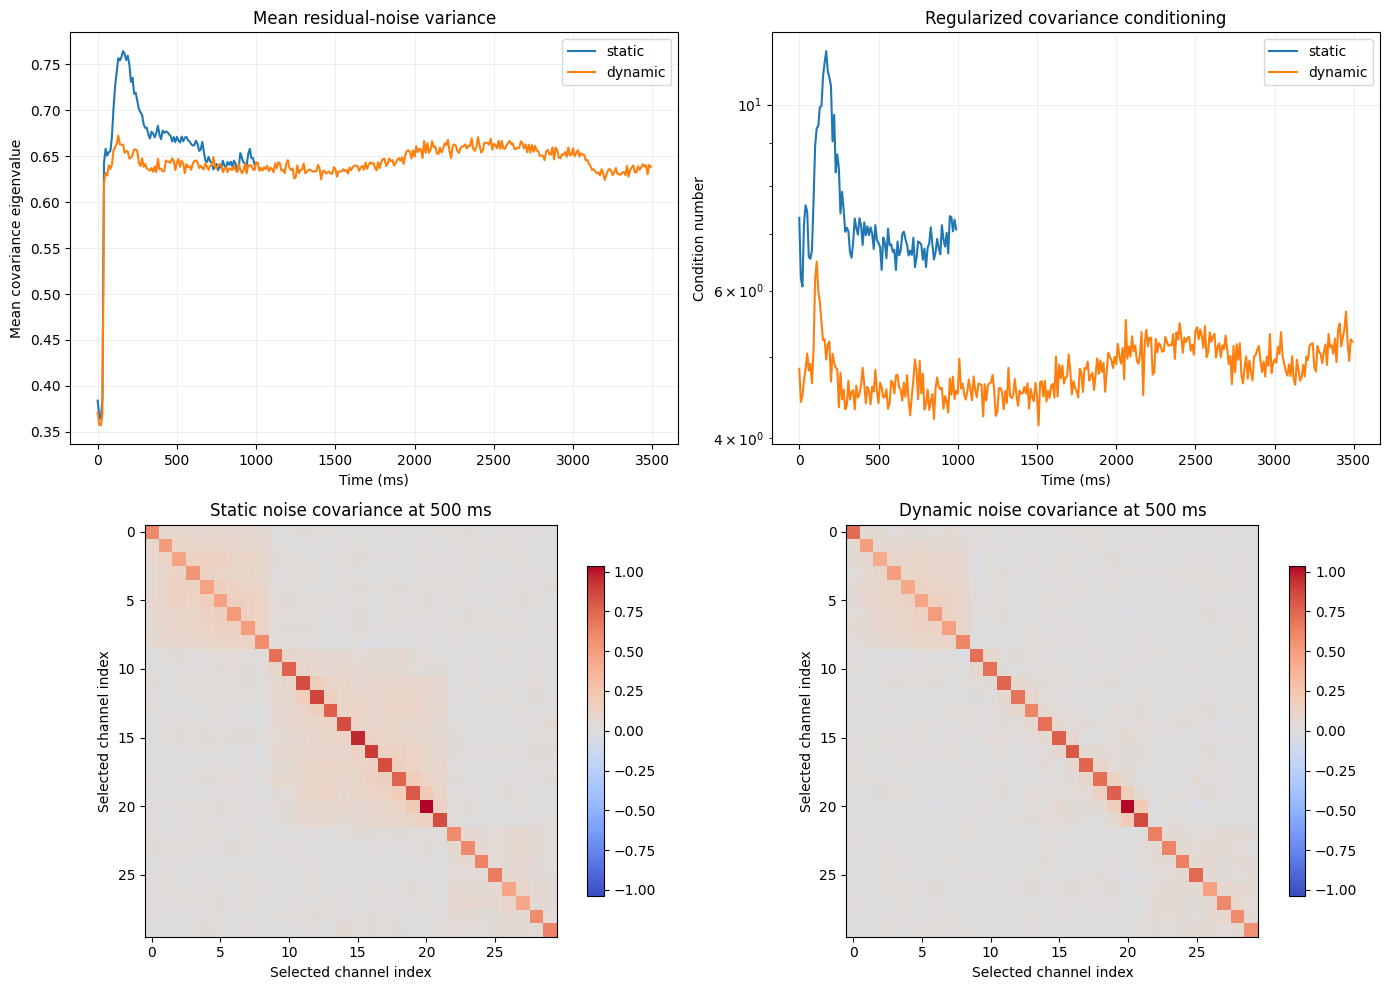

In [10]:
# Locate the requested covariance snapshots.
static_covariance_index = int(np.argmin(
    np.abs(static_times_ms - cfg.covariance_example_static_ms),
))
dynamic_covariance_index = int(np.argmin(
    np.abs(dynamic_times_ms - cfg.covariance_example_dynamic_ms),
))

figure, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].plot(
    static_times_ms, static_analysis["mean_noise_variances"],
    color="tab:blue", label="static",
)
axes[0, 0].plot(
    dynamic_times_ms, dynamic_analysis["mean_noise_variances"],
    color="tab:orange", label="dynamic",
)
axes[0, 0].set(
    title="Mean residual-noise variance", xlabel="Time (ms)",
    ylabel="Mean covariance eigenvalue",
)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.2)

axes[0, 1].semilogy(
    static_times_ms, static_analysis["condition_numbers"],
    color="tab:blue", label="static",
)
axes[0, 1].semilogy(
    dynamic_times_ms, dynamic_analysis["condition_numbers"],
    color="tab:orange", label="dynamic",
)
axes[0, 1].set(
    title="Regularized covariance conditioning", xlabel="Time (ms)",
    ylabel="Condition number",
)
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.2)

covariance_limit = max(
    np.abs(static_analysis["regularized_covariances"][static_covariance_index]).max(),
    np.abs(dynamic_analysis["regularized_covariances"][dynamic_covariance_index]).max(),
)
for axis, condition, analysis, time_index, times_ms in (
        (axes[1, 0], "static", static_analysis, static_covariance_index, static_times_ms),
        (axes[1, 1], "dynamic", dynamic_analysis, dynamic_covariance_index, dynamic_times_ms),
        ):
    image = axis.imshow(
        analysis["regularized_covariances"][time_index],
        cmap="coolwarm", vmin=-covariance_limit, vmax=covariance_limit,
    )
    axis.set(
        title=f"{condition.capitalize()} noise covariance at {times_ms[time_index]:g} ms",
        xlabel="Selected channel index", ylabel="Selected channel index",
    )
    figure.colorbar(image, ax=axis, shrink=0.8)
# end for covariance panel
figure.tight_layout()
plt.show()

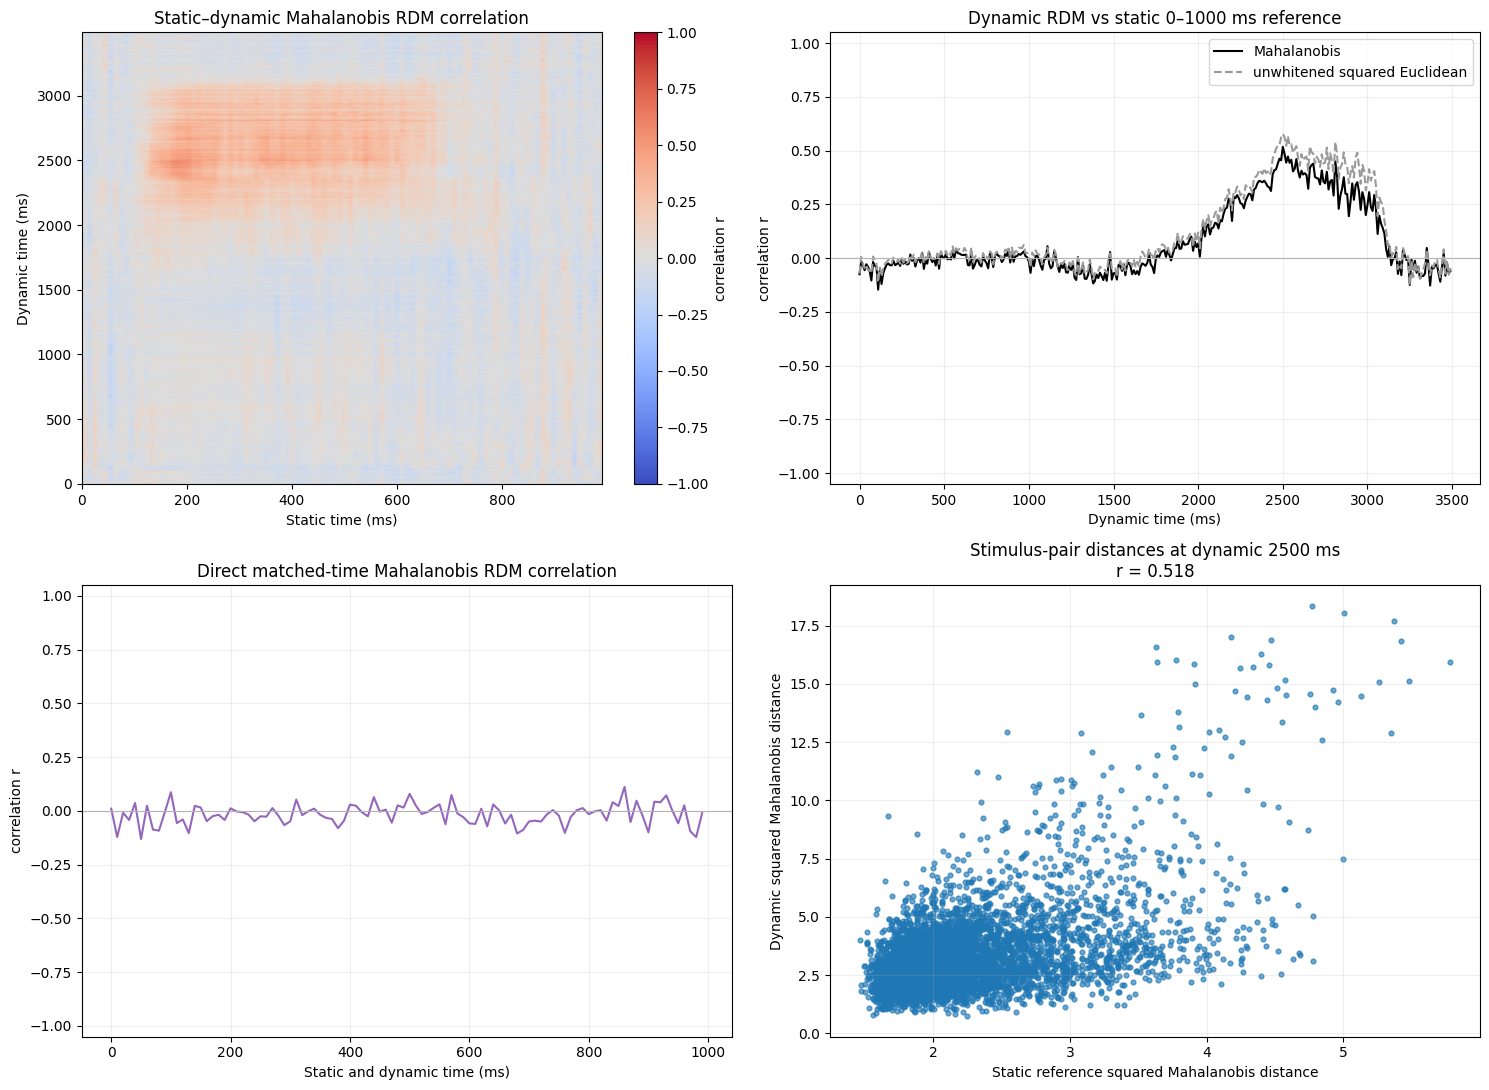

In [11]:
figure, axes = plt.subplots(2, 2, figsize=(15, 11))

image = axes[0, 0].imshow(
    static_dynamic_mahalanobis_similarity,
    origin="lower", aspect="auto", cmap="coolwarm", vmin=-1, vmax=1,
    extent=(
        static_times_ms[0], static_times_ms[-1],
        dynamic_times_ms[0], dynamic_times_ms[-1],
    ),
)
axes[0, 0].set(
    title="Static–dynamic Mahalanobis RDM correlation",
    xlabel="Static time (ms)", ylabel="Dynamic time (ms)",
)
figure.colorbar(image, ax=axes[0, 0], label=f"{cfg.rsa_metric} r")

axes[0, 1].plot(
    dynamic_times_ms, dynamic_vs_static_reference,
    color="black", label="Mahalanobis",
)
axes[0, 1].plot(
    dynamic_times_ms, dynamic_vs_static_reference_euclidean,
    color="0.6", linestyle="--", label="unwhitened squared Euclidean",
)
axes[0, 1].axhline(0, color="0.7", linewidth=0.8)
axes[0, 1].set(
    title=f"Dynamic RDM vs static {reference_start_ms:g}–{reference_end_ms:g} ms reference",
    xlabel="Dynamic time (ms)", ylabel=f"{cfg.rsa_metric} r", ylim=(-1.05, 1.05),
)
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.2)

axes[1, 0].plot(matched_times_ms, matched_time_similarity, color="tab:purple")
axes[1, 0].axhline(0, color="0.7", linewidth=0.8)
axes[1, 0].set(
    title="Direct matched-time Mahalanobis RDM correlation",
    xlabel="Static and dynamic time (ms)", ylabel=f"{cfg.rsa_metric} r",
    ylim=(-1.05, 1.05),
)
axes[1, 0].grid(alpha=0.2)

peak_dynamic_rdm = dynamic_mahalanobis_rdms[best_reference_index]
axes[1, 1].scatter(
    static_reference_mahalanobis_rdm, peak_dynamic_rdm, s=12, alpha=0.65,
)
axes[1, 1].set(
    title=(
        f"Stimulus-pair distances at dynamic {dynamic_times_ms[best_reference_index]:g} ms\n"
        f"r = {dynamic_vs_static_reference[best_reference_index]:.3f}"
    ),
    xlabel="Static reference squared Mahalanobis distance",
    ylabel="Dynamic squared Mahalanobis distance",
)
axes[1, 1].grid(alpha=0.2)

figure.tight_layout()
plt.show()

## Interpretation notes

- A high RDM correlation means static and dynamic responses preserve the same ordering of pairwise stimulus separations after each condition's correlated trial noise is discounted. It does **not** mean their absolute neural patterns or distance scales are identical.
- Pearson correlation tests agreement in relative distance geometry. Set `rsa_metric="spearman"` to test only distance ranks.
- `covariance_shrinkage` trades fidelity to the sample covariance against inverse stability. Inspect the condition-number curves and repeat the analysis over a reasonable range such as 0.05–0.2.
- These are regularized squared Mahalanobis distances from repetition-averaged patterns. They retain the usual positive noise bias in estimated distances. A split-half crossnobis analysis would be the appropriate extension if unbiased distance magnitudes, rather than RDM correlation, become the main target.